# CODE OVERVIEW

This code was developed by **Aritra Roy**, former *S.N. Bhatt Memorial Excellence Fellow (2024)* at the [International Centre for Theoretical Sciences (ICTS-TIFR), Bangalore](https://www.icts.res.in/news/results-icts-s-n-bhatt-memorial-excellence-fellowship-program-2024).

---

# 2D Stratified Fluid Turbulence Solver (Pseudo-Spectral Method)
This notebook implements a fully dealiased pseudo-spectral solver to simulate a two-dimensional, stably stratified, viscous fluid under the Boussinesq approximation. The flow is simulated in a square, doubly periodic domain $T^2 = [0, 2\pi) \times [0, 2\pi)$.

2D Stratified Fluid Turbulence Solver (Pseudo-Spectral Method)This notebook implements a fully dealiased pseudo-spectral solver to simulate a two-dimensional, stably stratified, viscous fluid under the Boussinesq approximation. The flow is simulated in a square, doubly periodic domain $T^2 = [0, 2\pi) \times [0, 2\pi)$. 

# Governing Equations💡
The mathematical framework and non-dimensional coupling configuration implemented in this simulation are based on the configurations detailed by Okino & Hanazaki (2020) in their study on direct numerical simulations of stratified fluid media: 

Okino, S., & Hanazaki, H. (2020). Direct numerical simulation of turbulence in a salt-stratified fluid. *Journal of Fluid Mechanics*, 891, A19. [doi:10.1017/jfm.2020.146](https://doi.org/10.1017/jfm.2020.146)

We solve the coupled system for the vertical vorticity component $\omega = \partial_x v - \partial_y u$ and the active scalar density fluctuation field $\rho$:$$\frac{\partial \omega}{\partial t} + \mathbf{u} \cdot \nabla \omega = \frac{1}{Re_0} \nabla^2 \omega - \frac{1}{Fr_0^2} \frac{\partial \rho}{\partial x}$$$$\frac{\partial \rho}{\partial t} + \mathbf{u} \cdot \nabla \rho = \frac{1}{Re_0 Sc} \nabla^2 \rho + v$$where:$\mathbf{u} = (u, v)$ is the incompressible velocity field satisfying $\nabla \cdot \mathbf{u} = 0$. $Re_0$ is the initial Reynolds number governing momentum diffusion.$Fr_0$ is the Froude number scaling the strength of the baroclinic torque.$Sc$ is the Schmidt number tracking mass/scalar diffusivity relative to viscosity.$-\frac{1}{Fr_0^2}\frac{\partial \rho}{\partial x}$ acts as the buoyancy generation term (Baroclinic Torque).$v$ represents the structural advection across the background linear density stratification profile.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2
from scipy.integrate import solve_ivp
from IPython.display import display, clear_output

## Simulation parameters for stratified flow

The provided code block initializes the key numerical and physical parameters for a **direct numerical simulation (DNS)** of a **stratified fluid flow**. Stratified flows occur when density variations (e.g., due to temperature or salinity gradients) interact with the velocity field, leading to phenomena such as internal waves, buoyancy-driven turbulence, and mixing. The setup corresponds to a canonical **incompressible, Boussinesq** approximation, where density fluctuations are neglected except in the buoyancy term.

The computational domain is a **2D periodic box** (likely representing a horizontal slice or a doubly periodic layer), with uniform grid spacing. The parameters are expressed in non‑dimensional form, which is standard for fundamental studies of turbulence and mixing.

---

### 1. **Non‑dimensional Control Parameters**

| Parameter | Value  | Description |
|-----------|--------|-------------|
| `Re0`     | 5000   | **Reynolds number** – ratio of inertial to viscous forces. Defines the intensity of turbulence and the scale separation. `Re = U L / ν`, where `U` is a characteristic velocity, `L` a characteristic length, and `ν` the kinematic viscosity. A value of 5000 is moderately high for 2D DNS, ensuring a significant inertial range but still resolvable with `1024²` grid points. |
| `Fr0`     | 7.0    | **Froude number** – ratio of inertial to buoyancy forces. `Fr = U / (N L)` where `N` is the buoyancy (Brunt‑Väisälä) frequency. `Fr > 1` indicates that inertia dominates over stratification; the flow is weakly stratified. For `Fr = 7`, buoyancy effects are relatively weak, but still influence large‑scale motions and energy transfers. |
| `Sc`      | 1.0    | **Schmidt number** – ratio of momentum diffusivity (viscosity) to mass diffusivity (of the scalar that encodes density). `Sc = ν / κ`. `Sc = 1` implies equal diffusivities, which is often used for simplicity in fundamental studies (e.g., temperature as a passive scalar in air). In many natural flows, `Sc` differs from unity (e.g., `Sc ~ 700` for salt in water), but setting `Sc = 1` reduces the number of active parameters. |

These three numbers (`Re`, `Fr`, `Sc`) completely characterise the non‑dimensional governing equations (the Boussinesq Navier‑Stokes equations coupled with a scalar transport equation).

---

# Simulation Domain & DiscretizationComputational Domain ($L_x = L_y = 2\pi$):
A square, doubly periodic domain where the flow wraps seamlessly in both directions.Using multiples of $\pi$ sets the fundamental wavenumber to $1$, simplifying the Fourier transforms.Eliminates complex wall boundary conditions (no-slip, inflow/outflow), isolating pure homogeneous turbulence and internal wave dynamics.

# Grid Resolution ($N_x = N_y = 1024$):
Generates a regular Cartesian mesh totaling $1,048,576$ grid points ($N_{xy}$) per physical field.Crucial for resolving the smallest dissipation scales (Kolmogorov scale) at high Reynolds numbers ($Re_0 = 5000$).Isotropic Grid Spacing ($\Delta x = \Delta y \approx 0.00613$):Perfectly uniform spacing ensures unbiased resolution for isotropic multi-scale features.Guarantees a high Nyquist cut-off wavenumber ($k_{max} = \frac{\pi}{\Delta x} \approx 512$) to fully capture dissipative scales before numerical truncation.

# Periodic Coordinate Arrays:
Built using np.linspace(..., endpoint=False) so $2\pi$ is excluded.Since $f(2\pi) \equiv f(0)$ by definition of periodicity, this prevents spatial double-counting and satisfies the strict continuous assumptions of the FFT.Degrees of Freedom (DoF):The dynamic state vector tracks $3 \times N_{xy}$ active variables per time step (Velocity fields $u, v$, and the active scalar density fluctuation $\rho$).Pressure is structurally eliminated via the incompressibility constraint ($\nabla \cdot \mathbf{u} = 0$), minimizing memory overhead while maintaining physical accuracy.

In [2]:
# =============================================================================
# 1. SIMULATION PARAMETERS (Stratified Flow)
# =============================================================================
Re0 = 5e3                  # Reynolds number
Fr0 = 7.0                     # Froude number
Sc  = 1.0                     # Schmidt number

Lx = 2 * np.pi                # Domain length in x
Ly = 2 * np.pi                # Domain length in y
Nx = 1024                      # Number of grid points in x (lowered for speed)
Ny = 1024                      # Number of grid points in y
dx = Lx / Nx                  # Uniform grid spacing in x
dy = Ly / Ny                  # Uniform grid spacing in y

# =============================================================================
# 2. COMPUTATIONAL DOMAIN & GRID GENERATION
# =============================================================================
x = np.linspace(0, Lx, Nx, endpoint=False)
y = np.linspace(0, Ly, Ny, endpoint=False)
Nxy = Nx * Ny                 # Degrees of freedom per field

# 2. Spectral Operators & Dealiasing:
This block initializes the discrete Fourier wavenumber spaces and precomputes the linear differential operators, converting spatial derivatives into algebraic multiplications ($\nabla \to i\mathbf{k}$).Wavenumber Mesh & Orszag $2/3$-RuleFor a grid of size $N$ on a $2\pi$ domain, the highest resolvable frequency without phase wrapping is the Nyquist limit ($k_{\text{Nyquist}} = N/2$).When evaluating non-linear advection terms like $\mathbf{u} \cdot \nabla \omega$ in physical space, high-frequency interactions generate modes that exceed this limit. These fold back into lower frequencies, creating unphysical aliasing errors. We eliminate this instability using Orszag's $2/3$-Rule, zeroing out the upper third of the spectrum along each axis:$$\hat{f}(\mathbf{k}) = 0 \quad \text{for} \quad |k_x| > \frac{N_x}{3} \quad \text{or} \quad |k_y| > \frac{N_y}{3}$$Incompressibility & Velocity ReconstructionTo satisfy the incompressibility constraint ($\nabla \cdot \mathbf{u} = 0$), we introduce a streamfunction $\psi$, defined by:$$u = \frac{\partial \psi}{\partial y}, \quad v = -\frac{\partial \psi}{\partial x}$$Substituting these into the vertical vorticity formula ($\omega = \partial_x v - \partial_y u$) yields the Poisson relationship $\nabla^2 \psi = -\omega$. In Fourier space, this differential equation simplifies to a direct algebraic inversion:$$\hat{\psi}(\mathbf{k}) = \frac{\hat{\omega}(\mathbf{k})}{|\mathbf{k}|^2} \quad (\text{where } |\mathbf{k}|^2 = k_x^2 + k_y^2 \neq 0)$$Using this solution, the velocity fields are reconstructed spectrally from vorticity via the precomputed multipliers $D_x$ and $D_y$:$$\hat{u}(\mathbf{k}) = i k_y \hat{\psi}(\mathbf{k}) = \left( \frac{i k_y}{|\mathbf{k}|^2} \right) \hat{\omega}(\mathbf{k}) = D_y \hat{\omega}(\mathbf{k})$$$$\hat{v}(\mathbf{k}) = -i k_x \hat{\psi}(\mathbf{k}) = \left( -\frac{i k_x}{|\mathbf{k}|^2} \right) \hat{\omega}(\mathbf{k}) = -D_x \hat{\omega}(\mathbf{k})$$Singularity Regularization: To avoid division-by-zero at the mean mode ($|\mathbf{k}|^2 = 0$), the origin of the inverse Laplacian matrix is explicitly set to zero ($K_{2\text{inv}}[0,0] = 0$).

In [3]:
# =============================================================================
# 3. FOURIER WAVENUMBERS & DEALIASING FILTER
# =============================================================================
kx = np.fft.fftfreq(Nx, d=dx / (2 * np.pi))
ky = np.fft.fftfreq(Ny, d=dy / (2 * np.pi))

# Orszag 2/3 Dealiasing Rule
kx[np.abs(kx) > (Nx / 3)] = 0.0
ky[np.abs(ky) > (Ny / 3)] = 0.0

Kx, Ky = np.meshgrid(kx, ky, indexing='xy')
K2 = Kx**2 + Ky**2

# =============================================================================
# 4. PRECOMPUTED SPECTRAL OPERATORS
# =============================================================================
K2inv = np.zeros_like(K2)
K2inv[K2 != 0] = 1.0 / K2[K2 != 0]

# Velocity reconstruction operators: u = i*ky/k^2, v = -i*kx/k^2
Dx = 1j * Kx * K2inv
Dy = 1j * Ky * K2inv

# 3. Initial Condition Generation:
   This block populates specific low-frequency Fourier modes with randomized amplitudes to initialize large-scale energetic eddies in the system.Large-Scale Forcing MechanicsRather than applying continuous external forcing during runtime, this simulation initializes turbulence via a transient, large-scale perturbation. Synthetic fluctuations are seeded exclusively into low-wavenumber spectral positions:
   $$\mathbf{k} \in \{(0, 4), (1, 1), (3, 0), (2, 2)\}$$

   By limiting the initial energy to modes where $|\mathbf{k}| \le 4$, we simulate energy injection at macro-scales. Over time, non-linear advection breaks these larger structures down, establishing a forward enstrophy cascade toward smaller dissipative scales.
   # Phase Randomization & Field Realization
   For each targeted mode, the complex Fourier coefficients $\hat{\omega}(\mathbf{k})$ and $\hat{\rho}(\mathbf{k})$ are sampled from a standard normal distribution:$$\hat{f}(\mathbf{k}) = A + iB \quad \text{where} \quad A, B \sim \mathcal{N}(0, 1)$$
   # Inverse Mapping:
   The multi-dimensional spectral array is transformed back into physical coordinates using the Inverse Fast Fourier Transform ($\text{IFFT}$).
   # Peak Normalization:
   Both spatial fields are divided by their respective absolute maximum values ($\max|\omega|$, $\max|\rho|$). This standardizes their initial maximum amplitudes to exactly $\pm 1$, ensuring a controlled, non-dimensionalized baseline at $t=0$.

In [4]:
# =============================================================================
# 5. INITIAL CONDITION GENERATION
# =============================================================================
np.random.seed(42)

def InitCond():
    Om_hat = np.zeros((Ny, Nx), dtype=complex)
    rho_hat = np.zeros((Ny, Nx), dtype=complex)

    # Inject random complex amplitudes into large-scale modes for both fields
    for k in [(0, 4), (1, 1), (3, 0), (2, 2)]:
        Om_hat[k] = np.random.randn() + 1j * np.random.randn()
        rho_hat[k] = np.random.randn() + 1j * np.random.randn()

    Om = np.real(ifft2(Om_hat))
    rho = np.real(ifft2(rho_hat))

    # Normalize fields
    Om /= np.max(np.abs(Om))
    rho /= np.max(np.abs(rho))
    
    return Om, rho

# 4. Right-Hand Side (RHS) & Time Discretization Loop:
   This block evaluates the instantaneous time-derivatives for the coupled state vector. The function is designed to interface directly with scipy.integrate.solve_ivp, utilizing a pseudo-spectral evaluation approach combined with a high-order adaptive time-stepping routine.
   
# The Pseudo-Spectral Mechanics (Space Fractional Steps)
Evaluating spatial derivatives via standard finite differences can introduce grid dispersion errors. Instead, we compute spatial operators in Fourier Space and evaluate nonlinear combinations in Physical Space:
# Velocity and Gradient Reconstruction:
Using the current state variables $\omega$ and $\rho$, spatial gradients are mapped algebraically using the Fourier identity $\nabla \to i\mathbf{k}$:$$\hat{u}(\mathbf{k}) = D_y \hat{\omega}(\mathbf{k}), \quad \hat{v}(\mathbf{k}) = -D_x \hat{\omega}(\mathbf{k})$$$$\nabla\hat{\omega}(\mathbf{k}) = (ik_x \hat{\omega}, \, ik_y \hat{\omega}), \quad \nabla\hat{\rho}(\mathbf{k}) = (ik_x \hat{\rho}, \, ik_y \hat{\rho})$$

# Physical-Space Non-Linear Mapping: 
Evaluating the convolution products $\mathbf{u} \cdot \nabla \omega$ and $\mathbf{u} \cdot \nabla \rho$ directly in spectral space requires expensive $\mathcal{O}(N^4)$ operations. To maximize efficiency, fields are transformed to physical coordinates via the Inverse Fast Fourier Transform ($\text{IFFT}$, $\mathcal{O}(N^2 \log N)$), multiplied point-by-point, and then handled as a standard vector:$$\mathbf{u} \cdot \nabla \omega = u \frac{\partial \omega}{\partial x} + v \frac{\partial \omega}{\partial y}, \quad \mathbf{u} \cdot \nabla \rho = u \frac{\partial \rho}{\partial x} + v \frac{\partial \rho}{\partial y}$$

# Linear Dissipation Terms:
Viscous diffusion and mass transport dissipation are calculated purely in Fourier space where the Laplacian operates as a scalar scaling function:$$\mathcal{F}\left\{\frac{1}{Re_0}\nabla^2\omega\right\} = -\frac{|\mathbf{k}|^2}{Re_0}\hat{\omega}, \quad \mathcal{F}\left\{\frac{1}{Re_0 Sc}\nabla^2\rho\right\} = -\frac{|\mathbf{k}|^2}{Re_0 Sc}\hat{\rho}$$

# Buoyancy Coupling Mechanisms:
Baroclinic Torque ($-\frac{1}{Fr_0^2}\frac{\partial \rho}{\partial x}$): Density gradients generate local horizontal buoyancy forces that directly feed back into the fluid's vorticity field.Background Stratification ($v$): Vertical velocity shifts fluid particles across the ambient, stable linear density gradient, driving density anomalies.

# Time Discretization & Adaptive Stepping Loop;
To advance the coupled semi-discrete system from $t \to t + \Delta t$, the code calls an explicit Runge-Kutta solver utilizing the RK45 (Dormand-Prince) embedding formulation.Explicit Runge-Kutta 4(5) StructureFor a generalized system state vector $\mathbf{Y} = [\omega, \rho]^T$ governed by $\frac{d\mathbf{Y}}{dt} = \mathbf{RHS}(t, \mathbf{Y})$, a single integration step calculates six intermediate stage rates $\mathbf{k}_m$:$$\mathbf{k}_1 = \mathbf{RHS}(t_n, \mathbf{Y}_n)$$$$\mathbf{k}_2 = \mathbf{RHS}\left(t_n + c_2\Delta t, \, \mathbf{Y}_n + \Delta t (a_{21}\mathbf{k}_1)\right)$$$$\vdots$$$$\mathbf{k}_6 = \mathbf{RHS}\left(t_n + c_6\Delta t, \, \mathbf{Y}_n + \Delta t \sum_{j=1}^{5} a_{6j}\mathbf{k}_j\right)$$Using these coefficients, two distinct approximations are evaluated simultaneously:$5^{\text{th}}$-Order Accurate Target Advance:$$\mathbf{Y}_{n+1} = \mathbf{Y}_n + \Delta t \sum_{m=1}^{6} b_m \mathbf{k}_m$$$4^{\text{th}}$-Order Accurate Reference Baseline:$$\mathbf{Y}^*_{n+1} = \mathbf{Y}_n + \Delta t \sum_{m=1}^{6} b^*_m \mathbf{k}_m$$Local Truncation Error (LTE) & Step OptimizationAt the end of each visualization interval interval $\Delta s$, the solver computes the local structural error:$$\mathbf{E}_{n+1} = \|\mathbf{Y}_{n+1} - \mathbf{Y}^*_{n+1}\|_\infty$$The adaptive controller continuously rescales the time-step sizes $\Delta t$ dynamically to guarantee the solver stays bounded by your specified tolerances (rtol=1e-5, atol=1e-5):$$\Delta t_{\text{new}} = \Delta t_{\text{old}} \times \left( \frac{\text{Tolerance}}{\mathbf{E}_{n+1}} \right)^{0.2}$$If $\mathbf{E}_{n+1} \le \text{Tolerance}$, the step is verified, the visualizer updates the plot data, and the state advances.If $\mathbf{E}_{n+1} > \text{Tolerance}$, the current path iteration is rejected and recomputed automatically with a smaller step size, preventing high-frequency numerical blowup.

In [5]:
# =============================================================================
# 4. RIGHT-HAND SIDE OF THE COUPLED SYSTEM
# =============================================================================
def RHS(t, state_vec):
    # Unpack the 1D state vector into 2D Vorticity and Density fields
    Om = state_vec[:Nxy].reshape((Ny, Nx))
    rho = state_vec[Nxy:].reshape((Ny, Nx))

    # Spectral transforms
    Om_hat = fft2(Om)
    rho_hat = fft2(rho)

    # Reconstruct velocities spectrally
    u = np.real(ifft2(Dy * Om_hat))
    v = np.real(ifft2(-Dx * Om_hat))

    # Compute spatial gradients spectrally
    Omx = np.real(ifft2(1j * Kx * Om_hat))
    Omy = np.real(ifft2(1j * Ky * Om_hat))
    rhox = np.real(ifft2(1j * Kx * rho_hat))
    rhoy = np.real(ifft2(1j * Ky * rho_hat))

    # Nonlinear advection (computed in physical space)
    adv_Om = u * Omx + v * Omy
    adv_rho = u * rhox + v * rhoy

    # Linear diffusion terms (computed in spectral space)
    diff_Om = np.real(ifft2(- (1.0 / Re0) * K2 * Om_hat))
    diff_rho = np.real(ifft2(- (1.0 / (Re0 * Sc)) * K2 * rho_hat))

    # Coupling terms
    baroclinic_torque = - (1.0 / Fr0**2) * rhox
    background_strat = v

    # Assemble RHS for each equation
    rhs_Om = diff_Om - adv_Om + baroclinic_torque
    rhs_rho = diff_rho - adv_rho + background_strat

    # Flatten and concatenate back into a single 1D array for solve_ivp
    return np.concatenate([rhs_Om.flatten(), rhs_rho.flatten()])

# 5. Time-Integration & Real-Time Visualization Loop:
This final block coordinates the execution of the fluid simulation, mapping the state calculations directly onto an interactive, self-updating visual display.
The integration duration and data tracking are controlled by two distinct parameters:

*   $T_f$: **Final simulation time** (total physical duration of the run).
*   $d_s$: **Visualization update interval** (stride for saving/displaying states).

> ### Key Distinction
> The routine `scipy.integrate.solve_ivp` internally utilizes **adaptive time-stepping** based on error tolerances. 
> Therefore, $d_s$ is **not** the numerical timestep ($\Delta t$). It only specifies **how frequently the solution is captured or visualized**.

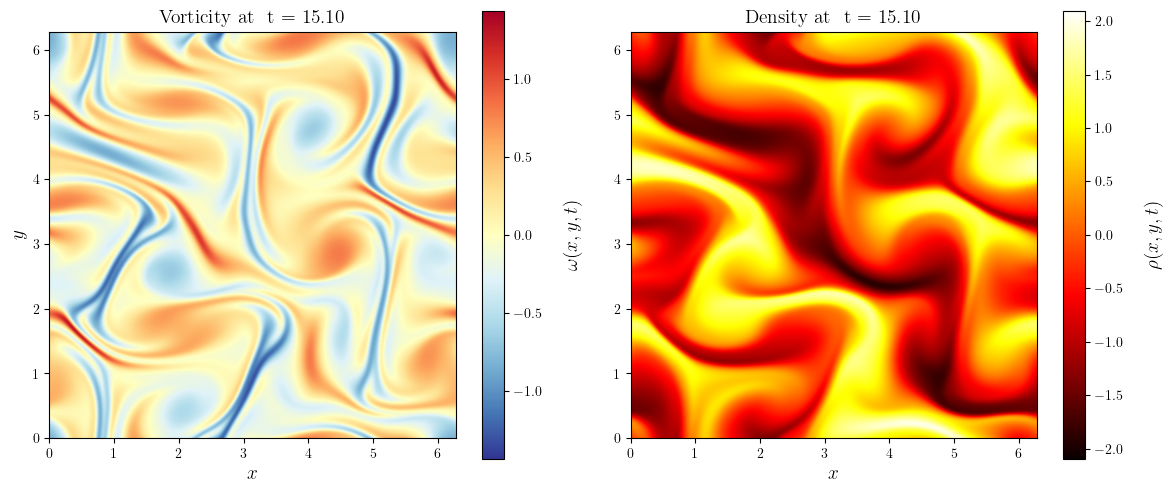

In [6]:
# =============================================================================
# 7. TIME-INTEGRATION & VISUALIZATION SETUP
# =============================================================================
t = 0.0
Tf = 15.0
ds = 0.1  # Visualization update interval

Om, rho = InitCond()
state_vec = np.concatenate([Om.flatten(), rho.flatten()])

# Matplotlib Configuration
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Setup Vorticity Plot
im1 = ax1.imshow(Om, extent=[0, Lx, 0, Ly], origin='lower', cmap='RdYlBu_r')
ax1.set_xlabel(r'$x$', fontsize=14)
ax1.set_ylabel(r'$y$', fontsize=14)
cbar1 = fig.colorbar(im1, ax=ax1)
cbar1.set_label(r'$\omega(x,y,t)$', rotation=90, fontsize=14, labelpad=15)
title1 = ax1.set_title(rf'\textrm{{Vorticity at }} t = {t:.2f}', fontsize=14)

# Setup Density Plot
im2 = ax2.imshow(rho, extent=[0, Lx, 0, Ly], origin='lower', cmap='hot')
ax2.set_xlabel(r'$x$', fontsize=14)
cbar2 = fig.colorbar(im2, ax=ax2)
cbar2.set_label(r'$\rho(x,y,t)$', rotation=90, fontsize=14, labelpad=15)
title2 = ax2.set_title(rf'\textrm{{Density at }} t = {t:.2f}', fontsize=14)

plt.tight_layout()

# =============================================================================
# 8. INTEGRATION LOOP
# =============================================================================
while t < Tf:
    # Integrate using RK45
    # Note: Tolerances relaxed slightly to 1e-5 for faster execution
    sol = solve_ivp(
        RHS,
        [t, t + ds],
        state_vec,
        method='RK45',
        rtol=1e-5,
        atol=1e-5
    )

    # Extract final state
    state_vec = sol.y[:, -1]
    Om = state_vec[:Nxy].reshape((Ny, Nx))
    rho = state_vec[Nxy:].reshape((Ny, Nx))
    t += ds

    # Dynamic limits for colorbars to handle growing amplitudes
    vmax_om = np.max(np.abs(Om)) + 0.1
    vmax_rho = np.max(np.abs(rho)) + 0.1
    
    im1.set_data(Om)
    im1.set_clim(-vmax_om, vmax_om)
    title1.set_text(rf'\textrm{{Vorticity at }} t = {t:.2f}')
    
    im2.set_data(rho)
    im2.set_clim(-vmax_rho, vmax_rho)
    title2.set_text(rf'\textrm{{Density at }} t = {t:.2f}')
    
    clear_output(wait=True)
    display(fig)

plt.close()

# 6. Energy and Enstrophy Turbulence Spectra Diagnostics:
This diagnostic block maps the 2D spatial fields into spectral wavenumber space to analyze how kinetic energy and enstrophy are distributed scale-by-scale across the flow.

# Spectral Power Definitions:
Using the 2D Fast Fourier Transform of the vorticity field $\hat{\omega}(\mathbf{k})$, where $\mathbf{k} = (k_x, k_y)$, the omnidirectional modal distributions are defined as:Kinetic Energy Spectrum ($E_{2D}$): Reconstructs the kinetic energy per unit mass. Using the identity $\hat{\mathbf{u}} \cdot \hat{\mathbf{u}}^* = \frac{|\hat{\omega}|^2}{|\mathbf{k}|^2}$, it is calculated as:$$E(\mathbf{k}) = \frac{1}{2}\frac{|\hat{\omega}(\mathbf{k})|^2}{k_x^2 + k_y^2}$$Enstrophy Spectrum ($Z_{2D}$): Measures the structural intensity of fluid rotations (mean-square vorticity):$$Z(\mathbf{k}) = \frac{1}{2}|\hat{\omega}(\mathbf{k})|^2$$Isotropic Radial Shell BinningTo reduce the 2D spectral planes into interpretable 1D wave profiles, the fields are integrated radially over concentric wavenumber shells using a fast histogram binning operation (np.histogram).For a continuous scalar shell radius $k = \sqrt{k_x^2 + k_y^2}$, the 1D isotropic distribution maps the sum of all directional modes matching a given magnitude wavenumber band:$$E(k) = \oint_{|\mathbf{k}|=k} E(\mathbf{k}) \, d\mathbf{k}, \quad Z(k) = \oint_{|\mathbf{k}|=k} Z(\mathbf{k}) \, d\mathbf{k}$$

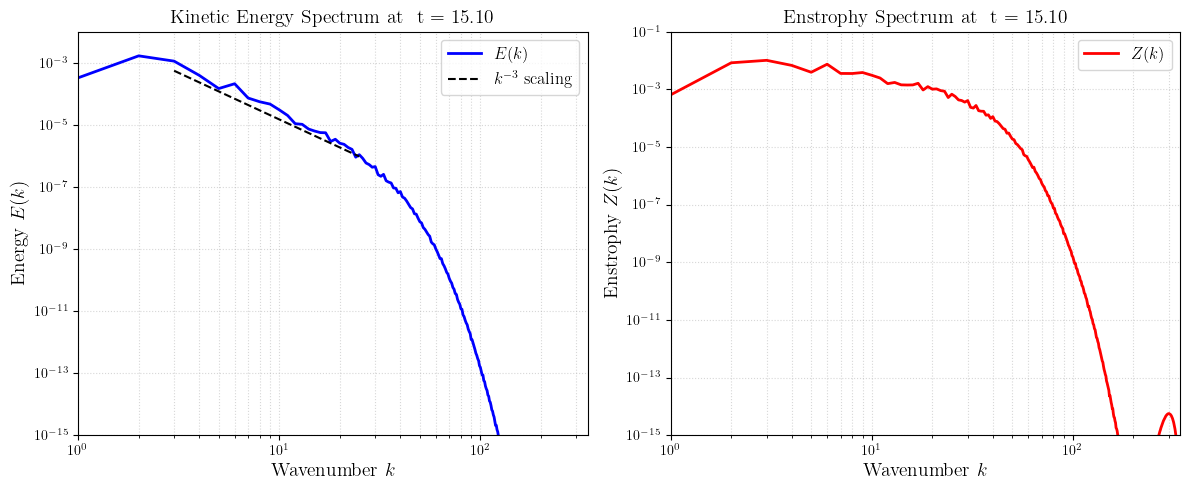

In [7]:
# =============================================================================
# 1. COMPUTE 1D ISOTROPIC SPECTRA FROM VORTICITY
# =============================================================================
# Compute 2D FFT of the current vorticity field and normalize
Om_hat = fft2(Om) / (Nx * Ny)

# Calculate Wavenumber Magnitude |k|
K_radial = np.sqrt(Kx**2 + Ky**2)

# Compute 2D Kinetic Energy and Enstrophy Spectrum
with np.errstate(divide='ignore', invalid='ignore'):
    E_2D = 0.5 * (np.abs(Om_hat)**2) / K2
E_2D[K2 == 0] = 0.0

Z_2D = 0.5 * np.abs(Om_hat)**2

# Define 1D wavenumber bins up to the Orszag 2/3 dealiasing limit
k_max = int(Nx // 3)
k_bins = np.arange(0.5, k_max + 1.5, 1.0)
k_vals = np.arange(1.0, k_max + 1.0)

# Radial binning (integration over shells) using histogram
E_1D, _ = np.histogram(K_radial.flatten(), bins=k_bins, weights=E_2D.flatten())
Z_1D, _ = np.histogram(K_radial.flatten(), bins=k_bins, weights=Z_2D.flatten())

# =============================================================================
# 2. VISUALIZATION (Side-by-Side Log-Log Plots)
# =============================================================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Kinetic Energy Spectrum E(k) ---
ax1.loglog(k_vals, E_1D, 'b-', linewidth=2, label=r'$E(k)$')

# Plot the k^-3 reference slope
slope_start_idx = 2
slope_end_idx = 25
ax1.loglog(
    k_vals[slope_start_idx:slope_end_idx], 
    1.5e-2 * (k_vals[slope_start_idx:slope_end_idx]**(-3.0)), 
    'k--', 
    linewidth=1.5, 
    label=r'$k^{-3}$ scaling'
)

ax1.set_xlabel(r'Wavenumber $k$', fontsize=14)
ax1.set_ylabel(r'Energy $E(k)$', fontsize=14)
ax1.set_title(rf'\textrm{{Kinetic Energy Spectrum at }} t = {t:.2f}', fontsize=14)
ax1.set_xlim(1, k_max)
ax1.set_ylim(1e-15, 1e-2)  # Truncate machine precision noise floor
ax1.grid(True, which="both", ls=":", alpha=0.5)
ax1.legend(fontsize=12)

# --- Plot 2: Enstrophy Spectrum Z(k) ---
ax2.loglog(k_vals, Z_1D, 'r-', linewidth=2, label=r'$Z(k)$')
ax2.set_xlabel(r'Wavenumber $k$', fontsize=14)
ax2.set_ylabel(r'Enstrophy $Z(k)$', fontsize=14)
ax2.set_title(rf'\textrm{{Enstrophy Spectrum at }} t = {t:.2f}', fontsize=14)
ax2.set_xlim(1, k_max)
ax2.set_ylim(1e-15, 1e-1)  # Truncate machine precision noise floor
ax2.grid(True, which="both", ls=":", alpha=0.5)
ax2.legend(fontsize=12)

plt.tight_layout()
plt.close(fig) 
display(fig)